In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import io
from datetime import datetime
import torch
import numpy as np
from model import *
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


In [ ]:
device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "xpu"
        if torch.xpu.is_available()
        else "cpu"
    )
print(f"Using {device} device")

In [ ]:
DIRECTORY = "ball_dataset"

### Récupération des 3 ratios les plus probables ###

In [ ]:
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from YOLO_loader import get_labels
import time


labels = get_labels(DIRECTORY)
ratios = []
for label in tqdm(labels, desc="Traitement des labels", leave=True):
    boxes = label.get_bounding_boxes()
    for box in boxes :
        box_ratios = box.get_ratio()
        ratios.append(box_ratios)  
    time.sleep(0)
    
ratios = np.array(ratios)
k = N_ANCHORS
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(ratios)  

labels = kmeans.labels_
centers = kmeans.cluster_centers_


plt.scatter(ratios[:, 0], ratios[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100)
plt.title("Clusters K-Means")
plt.show()

### CREATE TRAIN_SETTINGS ###

In [ ]:
from train_utils import TrainSettings
from YOLO_loader import get_classes

N_CLASS = len(get_classes(DIRECTORY))
NUM_EPOCHS = 20
BATCH_SIZE = 16
N_ANCHORS = 1
SEED = 42


torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

models = [
    LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=3,base_kernel_num=16,divider =1),
    LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=3,base_kernel_num=16,divider =1),
    LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=3,base_kernel_num=16,divider =1),
    LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=3,base_kernel_num=16,divider =1)
]

optimizer = torch.optim.Adam(models[0].parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

loss_fns = [YoloLoss(lambda_coord=5,lambda_noobj=0.5,lambda_obj=1),
            YoloLoss(lambda_coord=5,lambda_noobj=0.3,lambda_obj=3),
            YoloLoss(lambda_coord=5,lambda_noobj=0.1,lambda_obj=10),
            YoloLoss(lambda_coord=5,lambda_noobj=0.1,lambda_obj=20)]


TrainSettingsArray = [
    TrainSettings(N_CLASS,NUM_EPOCHS,BATCH_SIZE,1,centers,N_ANCHORS,scheduler,optimizer,loss_fns[0]),
    TrainSettings(N_CLASS,NUM_EPOCHS,BATCH_SIZE,1,centers,N_ANCHORS,scheduler,optimizer,loss_fns[1]),
    TrainSettings(N_CLASS,NUM_EPOCHS,BATCH_SIZE,1,centers,N_ANCHORS,scheduler,optimizer,loss_fns[2]),
    TrainSettings(N_CLASS,NUM_EPOCHS,BATCH_SIZE,1,centers,N_ANCHORS,scheduler,optimizer,loss_fns[3])
]

for i in range(len(TrainSettingsArray)):
    TrainSettingsArray[i].create_experiment_folder(models[i])

### CREATE DATASET ###


In [7]:
from dataset import CardRecognitionDataset

reduction_factor = models[0].get_reduction_factor()

dataset = CardRecognitionDataset(directory= DIRECTORY,is_dark_and_white=False,reduction_factor=reduction_factor,bounding_boxes_ratio=centers)
STD = dataset.get_std()
MEAN = dataset.get_mean()

Mean: [0.485, 0.456, 0.406]
Std:  [0.229, 0.224, 0.225]


### CREATE DATA LOADER ###

In [8]:
from dataset import custom_collate_fn, CustomBatchSampler
from torch.utils.data import Subset,DataLoader
import random

N = dataset.__len__()
train_size = int(0.7 * N)
val_size   = int(0.2 * N)   
indices = torch.randperm(N)
test_size  = N - train_size - val_size

full_groups = dataset.get_image_size_groups()

train_groups = {}
val_groups = {}
test_groups = {}

# 2. Diviser CHAQUE groupe en Train/Val/Test pour préserver l'équilibre des tailles
for size, indices in full_groups.items():
    # Mélanger les indices de ce groupe spécifique
    random.shuffle(indices)
    
    n_total = len(indices)
    n_train = int(0.7 * n_total)
    n_val   = int(0.2 * n_total)
    
    train_groups[size] = indices[:n_train]
    val_groups[size]   = indices[n_train:n_train+n_val]
    test_groups[size]  = indices[n_train+n_val:]

# 3. Créer les Samplers avec ces groupes filtrés
train_sampler = CustomBatchSampler(dataset, BATCH_SIZE, groups=train_groups)
val_sampler   = CustomBatchSampler(dataset, BATCH_SIZE, groups=val_groups)
test_sampler  = CustomBatchSampler(dataset, BATCH_SIZE, groups=test_groups)

# 4. Créer les DataLoaders
train_loader = DataLoader(dataset, batch_sampler=train_sampler, collate_fn=custom_collate_fn, num_workers=0)
val_loader   = DataLoader(dataset, batch_sampler=val_sampler,   collate_fn=custom_collate_fn, num_workers=0)
test_loader  = DataLoader(dataset, batch_sampler=test_sampler,  collate_fn=custom_collate_fn, num_workers=0)

print(len(dataset))
print(len(train_loader))

126
6


### TRAINING ###

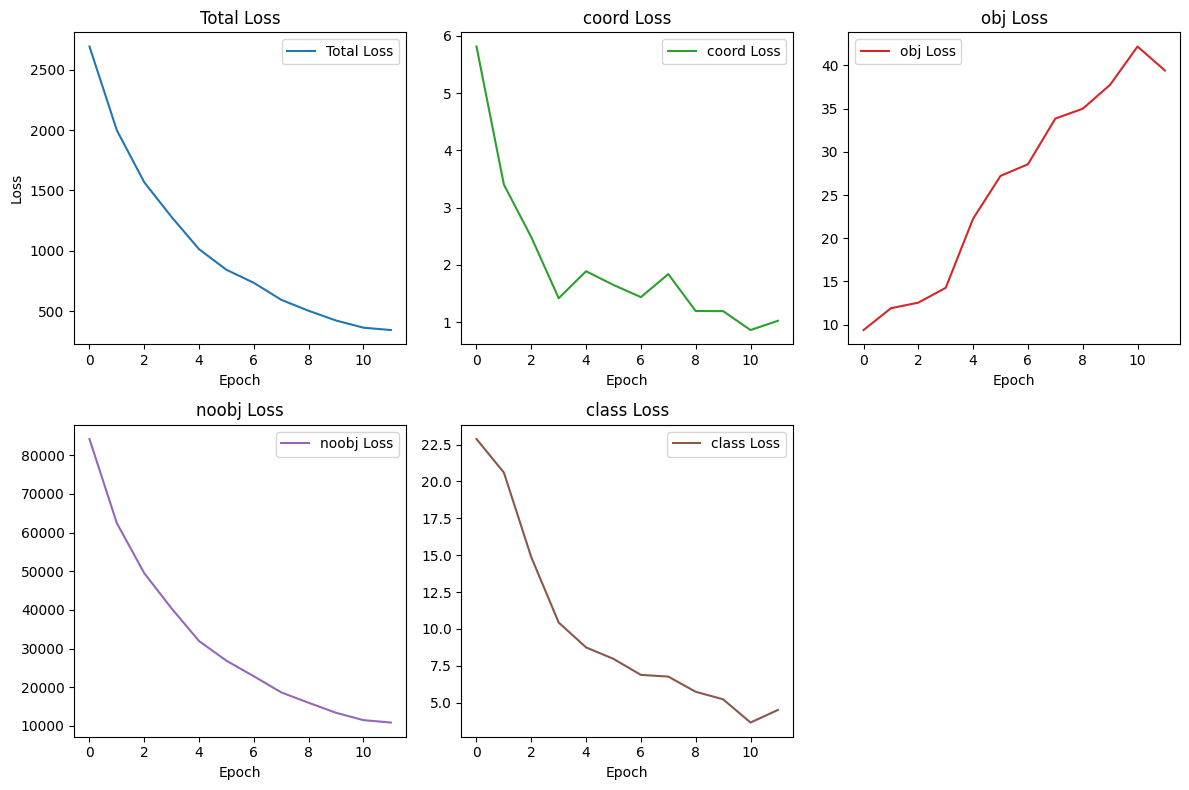

batch :  50%|█████     | 1/2 [00:08<00:08,  8.72s/it]


KeyboardInterrupt: 

In [9]:
from train_utils import run_one_epoch

for i in range(len(TrainSettingsArray)):
    model = models[i]
    training_settings = TrainSettingsArray[i]
    epochs_loss = []
    for epoch in range(training_settings.num_epochs):
        loss = run_one_epoch(train_loader,model,training_settings.loss_fn,training_settings.optimizer,training_settings.scheduler,device,training_settings.num_classes,reduction_factor,centers,N_ANCHORS,train=True)
        val_loss = run_one_epoch(val_loader,model,training_settings.loss_fn,training_settings.optimizer,training_settings.scheduler,device,training_settings.num_classes,reduction_factor,centers,N_ANCHORS,train=False)
        epochs_loss.append(val_loss)
        print(f"Epoch {epoch} loss: {val_loss} (type: {type(val_loss)})")
    training_settings.create_experiment_folder(model,base_dir="ball_models")

### TEST ###

In [ ]:
torch.save(model.state_dict(), 'models/ballV4.pth')